# **Training FACE ID Spoof Detector Model**

In [1]:
!pip install facenet-pytorch grad-cam

# Load Dataset

In [2]:

import zipfile
import os

# Unzip the dataset
zip_path = 'Dataset_Spoof_Detector.zip'
extract_dir = './Dataset_Spoof_Detector'

if not os.path.exists(extract_dir):
    if os.path.exists(zip_path):
        print(f"Extracting {zip_path}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)
        print("Extraction complete.")
    else:
        print(f"Error: {zip_path} not found. Please upload it to the current directory.")
else:
    print(f"Dataset already extracted at {extract_dir}")


Dataset already extracted at ./Dataset_Spoof_Detector


# Data transformation and augmentation

In [3]:
from torchvision import transforms

# Image size for InceptionResnetV1 is typically 160x160, but handles 224 perfectly fine
IMG_SIZE = 224

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), #safe guard
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3), # Randomly change the brightness, contrast, saturation and hue of an image.
    transforms.ToTensor(),

])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), #safeguard
    transforms.ToTensor(),

])


#  Split into Training and validation set


In [4]:
from torchvision import datasets
from torch.utils.data import DataLoader, random_split, Subset
import torch


# Load the full dataset
dataset_path = './Dataset_Spoof_Detector/Dataset_Spoof_Detector'
full_dataset = datasets.ImageFolder(root=dataset_path)

print(f"Detected classes: {full_dataset.classes}")
print(full_dataset.class_to_idx)

# Separate indices based on location in filename
test_indices = []
train_val_indices = []

for i, (path, _) in enumerate(full_dataset.samples):
    filename = os.path.basename(path).lower()
    # Filename format: <real or spoof>_<location>_<extra info>.jpg
    # We check if 'bathroom' is in the filename
    if 'bathroom' in filename:
        test_indices.append(i)
    else:
        train_val_indices.append(i)

# Create the test set with only bathroom images
test_data_raw = Subset(full_dataset, test_indices)

# Split the remaining data into Train (80%) and Val (20%)
remaining_size = len(train_val_indices)
train_size = int(0.8 * remaining_size)
val_size = remaining_size - train_size

# Create a subset of the remaining data, then randomly split it
train_val_subset = Subset(full_dataset, train_val_indices)
train_data_raw, val_data_raw = random_split(train_val_subset, [train_size, val_size])

# Apply the transformations to each split
class TransformedDataset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform: x = self.transform(x)
        return x, y
    def __len__(self):
        return len(self.subset)

train_set = TransformedDataset(train_data_raw, transform=train_transforms)
val_set = TransformedDataset(val_data_raw, transform=val_transforms)
test_set = TransformedDataset(test_data_raw, transform=val_transforms)

print(f"Training set size: {len(train_set)}")
print(f"Validation set size: {len(val_set)}")
print(f"Test set (Bathroom only) size: {len(test_set)}")

Detected classes: ['Real_Images', 'Spoof_Images']
{'Real_Images': 0, 'Spoof_Images': 1}
Training set size: 1668
Validation set size: 417
Test set (Bathroom only) size: 494


# Data Loaders

In [5]:
BATCH_SIZE = 16

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)# Avoid memorizing order in training
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

# Check by extracting one batch
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}") # Should be [16(images in batch), 3(color channels), 224, 224]

Batch shape: torch.Size([16, 3, 224, 224])


# Print first 5 images in training and validation

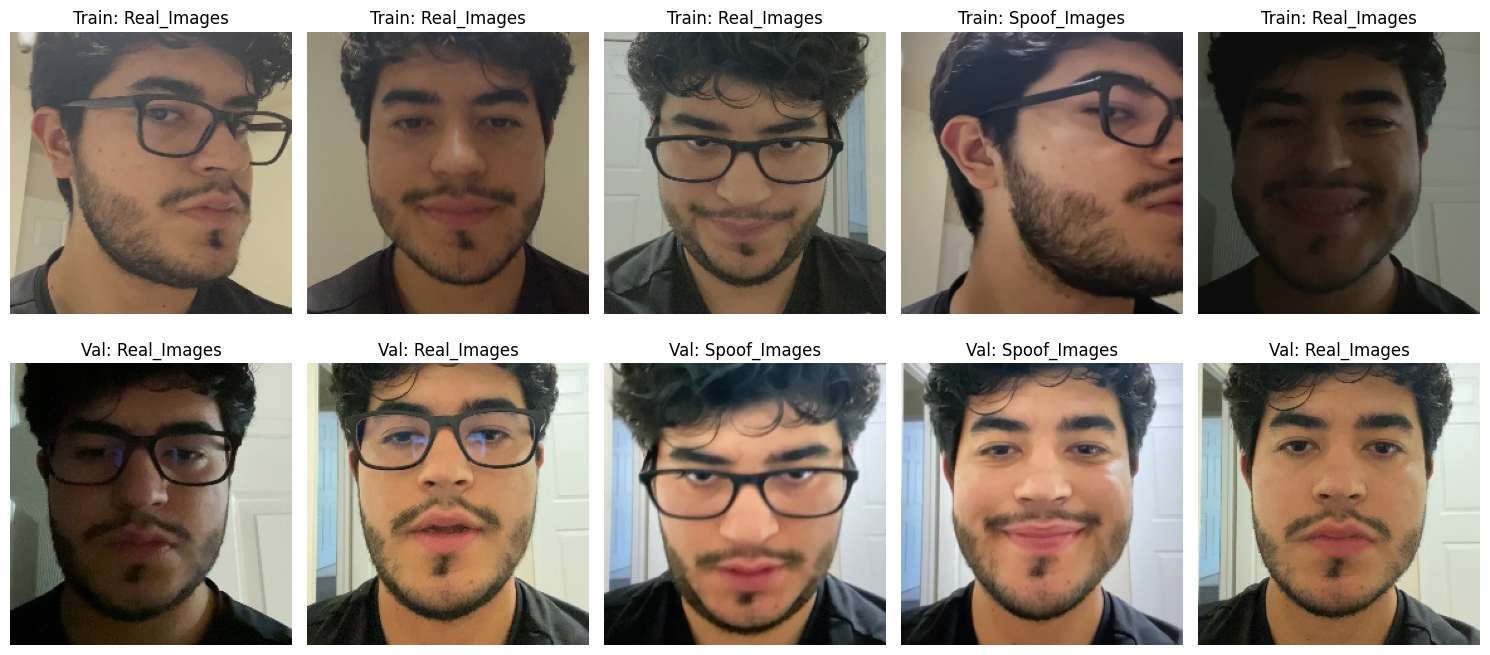

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Get the list of names from the root dataset
class_names = full_dataset.classes

# 2. Grab batches from both loaders
train_images, train_labels = next(iter(train_loader))
val_images, val_labels = next(iter(val_loader))

plt.figure(figsize=(15, 7))

# Helper function to display image
def imshow_batch(images, labels, start_idx, row, title_prefix):
    for i in range(5):
        plt.subplot(2, 5, start_idx + i)

        img = images[i].permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)

        class_index = labels[i].item()
        label_name = class_names[class_index]

        plt.imshow(img)
        plt.title(f"{title_prefix}: {label_name}")
        plt.axis('off')

# 3. Plot 5 Training Images (Top Row)
imshow_batch(train_images, train_labels, 1, 0, "Train")

# 4. Plot 5 Validation Images (Bottom Row)
imshow_batch(val_images, val_labels, 6, 1, "Val")

plt.tight_layout()
plt.show()

# Import model FACENET (InceptionResnetV1)

In [7]:
import torch
import torch.nn as nn
from facenet_pytorch import InceptionResnetV1

class SpoofDetector(nn.Module):
    def __init__(self, num_classes=2):
        super(SpoofDetector, self).__init__()
        """
        As recommended by professor, I looked for a face recognition neural network
        # Model FACENET, paper: https://arxiv.org/abs/1503.03832 , takeaways Triplet loss and L2 Normalization
        # Implementation of facenet in pytorch: https://github.com/timesler/facenet-pytorch/
        # This implementation uses InceptionResnetV1 proposed in Inception-v4, Inception-ResNet and
the Impact of Residual Connections on Learning, https://arxiv.org/pdf/1602.07261
        # Implementattion of facenet in tensorflow: David Sandberg's facenet repo: https://github.com/davidsandberg/facenet
        # Data set used: VGGFace2 https://arxiv.org/abs/1710.08092
        """
        # Load pre-trained InceptionResnetV1 on vggface2
        # classify=False "Whether the model should output classification probabilities or feature embeddings.""
        # Beacause we want to classify between real and spoof , we chop the last layer and get a 512 dimensional feature vector
        self.backbone = InceptionResnetV1(pretrained='vggface2', classify=False)

        # Our Custom classification head
        # takes the 512 features and maps them to 2 values(real or spoof)
        self.fc = nn.Sequential(
            #nn.Dropout(0.5), Prevent from overfitting?
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        # Pass through the facenet backbone
        x = self.backbone(x)
        # Pass through classification head
        return self.fc(x)

# Instantiate and move to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SpoofDetector(num_classes=2).to(device)

print(f"Model loaded and sent to {device}")


Model loaded and sent to cuda


#Setup loss and optimizer


In [8]:
import torch.optim as optim
"""
Loss for multi-class classification
Answers: How good are the predicted probabilities?
# Step 1: My neural network outputs logits(unnormalized numbers) per image, ex: [2.5, -1.2]
# Step 2: Softmax to convert logits into probabilities [2.5, -1.2] might become [0.97, 0.03], meaning a 97% confidence in class 0 and 3% in class 1.
# Step 3: Penalty = negative log likelihood {-log(x)} ONLY looks at the probability of the correct class
  If the true class is 0, and the model predicted a 97% probability for class 0, -log(0.97) is a very low loss (near 0).
  If the true class was 1, and the model predicted a 3% probability for class 1, -log(0.03) yields a very high loss.
"""
criterion = nn.CrossEntropyLoss()

# Freeze backbone completely for Stage 1 by setting every parameter to dont require gradient(not update)
for param in model.backbone.parameters():
    param.requires_grad = False

# Loop new classification head and set to trainable
for param in model.fc.parameters():
    param.requires_grad = True
"""
Adam optimizer (for the head only)
Optimizer: Adjust models weights to minimize loss.
Momentum(remember past gradients to maintain velocity in the right direction) + RMSprop(remember past squared gradients and adjust learning rate to avoid bouncing)
"""
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)


#Train

In [9]:
import time
import copy

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=15):
    since = time.time()
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    #create a copy of the current model weights
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss, running_corrects = 0.0, 0

            for inputs, labels in dataloader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()# erase previous gradients

                with torch.set_grad_enabled(phase == 'train'):
                    # Look at batch and make predictions, output = logits
                    outputs = model(inputs)
                    # Save predicted classes
                    _, preds = torch.max(outputs, 1)
                    # Calculate loss
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        # Calculate gradient to adjust weights
                        loss.backward()
                        # update models weights
                        optimizer.step()

                # avg loss * batch size
                running_loss += loss.item() * inputs.size(0)
                # count how many predictions matched the label
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

                # deep copy the model if it has the best validation accuracy
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

    time_elapsed = time.time() - since
    print(f'Training complete in {int(time_elapsed // 60)}m {int(time_elapsed % 60)}s')
    print(f'Best val Acc: {best_acc:4f}')

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model, history


In [10]:
# --- STAGE 1: WARM UP THE HEAD (5 Epochs) ---
print("Stage 1: Training only the final custom layer...")
model, history1 = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5)

# --- STAGE 2: UNFREEZE AND FINE-TUNE (10 Epochs) ---
print("\nStage 2: Unfreezing final blocks of backbone...")

# Unfreeze only the later blocks of the InceptionResnet for stability
# ONlY blocks 8 and those that contain last
for name, param in model.backbone.named_parameters():
    if 'block8' in name or 'last' in name:
        param.requires_grad = True

# Different Learning Rates to avoid breaking backbone while learning spoof
optimizer = optim.Adam([
    {'params': [p for n, p in model.backbone.named_parameters() if p.requires_grad], 'lr': 1e-5}, # small learning rate for backbone(block 8 and last)
    {'params': model.fc.parameters(), 'lr': 1e-4} # 10 x bigger rate for custom last layer
], weight_decay=1e-3) # penalize large weights

# Fine-tune
model, history2 = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10)


Stage 1: Training only the final custom layer...
Epoch 1/5
----------
Train Loss: 0.6707 Acc: 0.6535
Val Loss: 0.6399 Acc: 0.7290
Epoch 2/5
----------
Train Loss: 0.6281 Acc: 0.7068
Val Loss: 0.5914 Acc: 0.8177
Epoch 3/5
----------
Train Loss: 0.6042 Acc: 0.7206
Val Loss: 0.5635 Acc: 0.8177
Epoch 4/5
----------
Train Loss: 0.5790 Acc: 0.7350
Val Loss: 0.5370 Acc: 0.8106
Epoch 5/5
----------
Train Loss: 0.5611 Acc: 0.7422
Val Loss: 0.5149 Acc: 0.8177
Training complete in 0m 44s
Best val Acc: 0.817746

Stage 2: Unfreezing final blocks of backbone...
Epoch 1/10
----------
Train Loss: 0.5821 Acc: 0.7530
Val Loss: 0.5183 Acc: 0.8489
Epoch 2/10
----------
Train Loss: 0.5058 Acc: 0.8321
Val Loss: 0.4220 Acc: 0.8897
Epoch 3/10
----------
Train Loss: 0.4230 Acc: 0.8711
Val Loss: 0.3623 Acc: 0.8993
Epoch 4/10
----------
Train Loss: 0.3421 Acc: 0.8963
Val Loss: 0.5132 Acc: 0.7098
Epoch 5/10
----------
Train Loss: 0.2701 Acc: 0.9197
Val Loss: 0.2239 Acc: 0.9424
Epoch 6/10
----------
Train Loss: 0.

In [11]:
model.eval()
dummy_input = torch.randn(1, 3, 224, 224).to(device)
traced_model = torch.jit.trace(model, dummy_input)
traced_model.save("./model.pt")

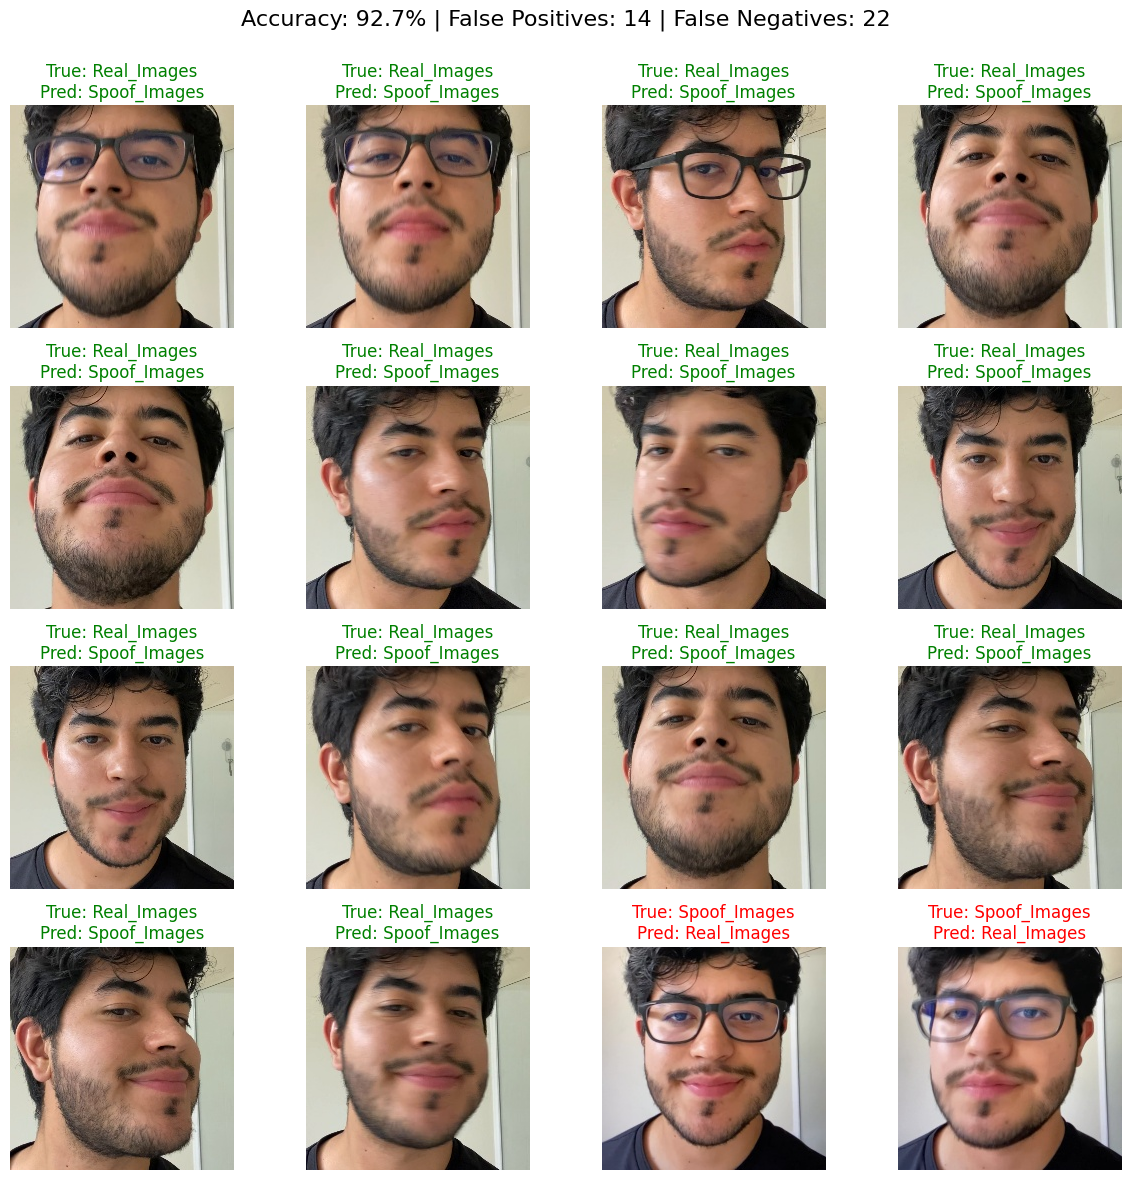

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# --- Error Analysis Grid ---
model.eval()
errors = []
error_labels = []
error_preds = []

class_names = full_dataset.classes

total_samples = 0
total_correct = 0
false_positives = 0
false_negatives = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        # predict
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        total_samples += labels.size(0)
        total_correct += (preds == labels).sum().item()

        # 'Real_Images' is class 0 and 'Spoof_Images' is class 1
        # False Positive: predicted spoof (1) but true is real (0)
        # False Negative: predicted real (0) but true is spoof (1)
        false_positives += ((preds == 1) & (labels == 0)).sum().item()
        false_negatives += ((preds == 0) & (labels == 1)).sum().item()

        # Find mismatches
        mismatches = (preds != labels).nonzero(as_tuple=True)[0]

        for idx in mismatches:
            if len(errors) < 16:
                errors.append(inputs[idx].cpu()) # image tensor
                error_labels.append(labels[idx].item()) # actual label
                error_preds.append(preds[idx].item()) # prediction

accuracy = (total_correct / total_samples) * 100 if total_samples > 0 else 0.0

if len(errors) > 0:
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    subtitle_str = f"Accuracy: {accuracy:.1f}% | False Positives: {false_positives} | False Negatives: {false_negatives}"

    # Set title
    fig.suptitle(subtitle_str, fontsize=16)

    axes = axes.flatten()

    for i in range(min(16, len(errors))):

        img = errors[i].permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)

        true_label = error_labels[i]
        pred_label = error_preds[i]

        true_class = class_names[true_label]
        pred_class = class_names[pred_label]

        # Determine text color: Green for False Positives, Red for False Negatives
        # False Positive: predicted spoof (1), actual real (0)
        title_color = 'green' if (pred_label == 1 and true_label == 0) else 'red'

        axes[i].imshow(img)
        axes[i].set_title(f"True: {true_class}\nPred: {pred_class}", color=title_color)
        axes[i].axis('off')

    # Turn off any unused axes if there are fewer than 16 errors
    for i in range(len(errors), 16):
        axes[i].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9) # Provide space for the suptitle
    plt.show()
else:
    print(f"No errors found in the test set! Accuracy: {accuracy:.1f}%")


Computing average Grad-CAMs over the test set. 


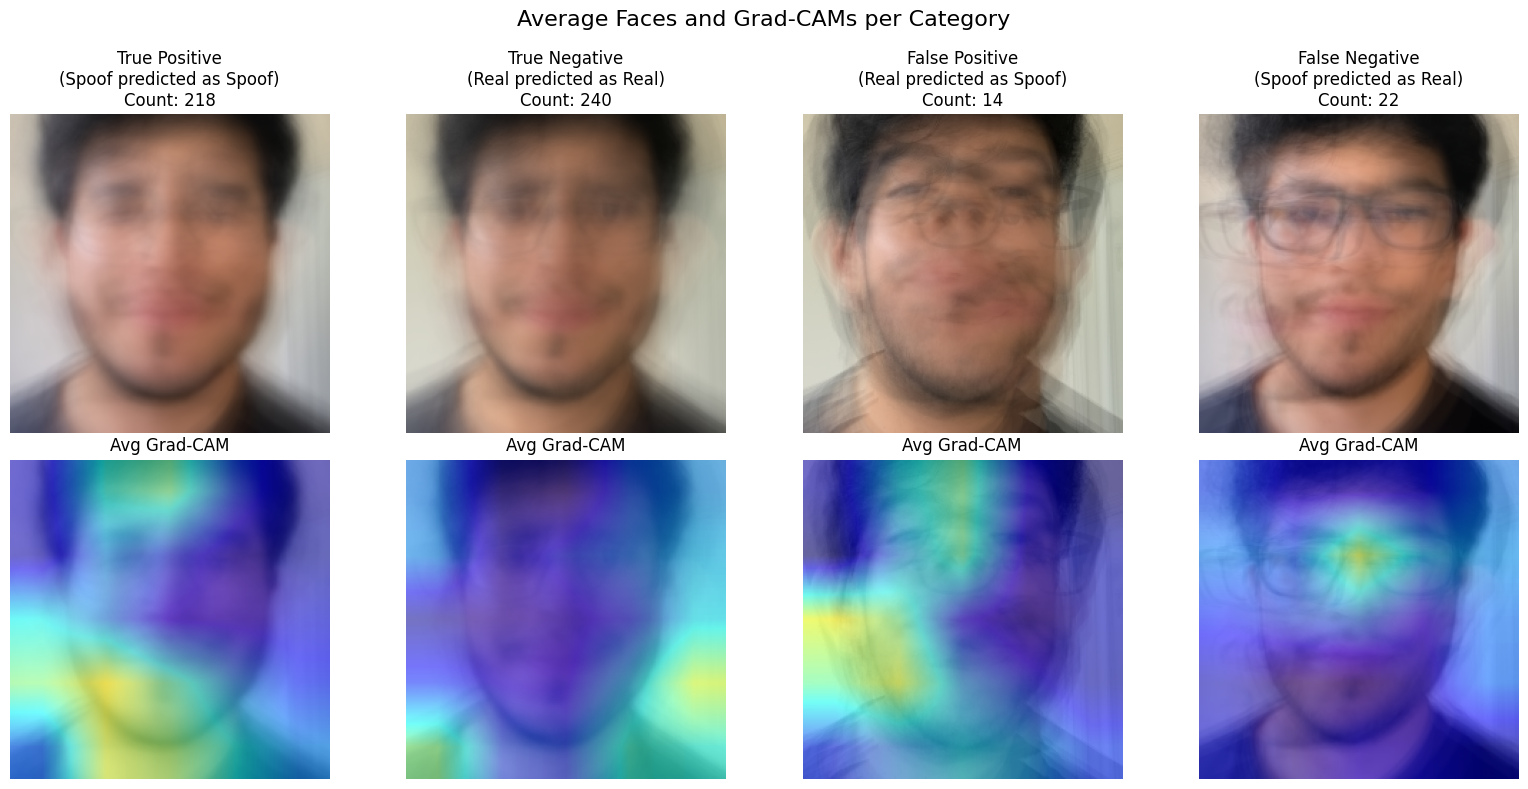

In [ ]:
# --- Average Grad-CAM Visualization ---
# Library used: pytorch-grad-cam https://github.com/jacobgil/pytorch-grad-cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch

# Target the last convolutional block of the InceptionResnetV1 backbone.
target_layers = [model.backbone.block8.conv2d]
cam = GradCAM(model=model, target_layers=target_layers)

# Dictionary to store the sum of images and cams, and the count for averages
stats = {
    'TP': {'img_sum': None, 'cam_sum': None, 'count': 0}, # True Spoof, Pred Spoof
    'TN': {'img_sum': None, 'cam_sum': None, 'count': 0}, # True Real, Pred Real
    'FP': {'img_sum': None, 'cam_sum': None, 'count': 0}, # True Real, Pred Spoof
    'FN': {'img_sum': None, 'cam_sum': None, 'count': 0}, # True Spoof, Pred Real
}

model.eval()

print("Computing average Grad-CAMs over the test set. ")

for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    outputs = model(inputs)
    _, preds = torch.max(outputs, 1)

    # Compute CAMs for the entire batch at once for efficiency
    with torch.enable_grad():
        targets = [ClassifierOutputTarget(p.item()) for p in preds]
        grayscale_cam_batch = cam(input_tensor=inputs, targets=targets)

    for i in range(inputs.size(0)):
        true_label = labels[i].item()
        pred_label = preds[i].item()

        # Determine category
        if true_label == 1 and pred_label == 1:
            cat = 'TP'
        elif true_label == 0 and pred_label == 0:
            cat = 'TN'
        elif true_label == 0 and pred_label == 1:
            cat = 'FP'
        elif true_label == 1 and pred_label == 0:
            cat = 'FN'

        grayscale_cam = grayscale_cam_batch[i, :]
        img_np = inputs[i].cpu().permute(1, 2, 0).numpy()

        # Accumulate sums
        if stats[cat]['count'] == 0:
            stats[cat]['img_sum'] = np.copy(img_np)
            stats[cat]['cam_sum'] = np.copy(grayscale_cam)
        else:
            stats[cat]['img_sum'] += img_np
            stats[cat]['cam_sum'] += grayscale_cam

        stats[cat]['count'] += 1

# --- Plotting ---
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Average Faces and Grad-CAMs per Category", fontsize=16)

cats = ['TP', 'TN', 'FP', 'FN']
titles = [
    'True Positive\n(Spoof predicted as Spoof)',
    'True Negative\n(Real predicted as Real)',
    'False Positive\n(Real predicted as Spoof)',
    'False Negative\n(Spoof predicted as Real)'
]

for i, cat in enumerate(cats):
    count = stats[cat]['count']
    if count > 0:
        # Calculate averages
        avg_img = stats[cat]['img_sum'] / count
        avg_cam = stats[cat]['cam_sum'] / count

        avg_img = np.clip(avg_img, 0, 1)

        # Generate CAM overlaid on image
        cam_image = show_cam_on_image(avg_img, avg_cam, use_rgb=True)

        # Plot Average Image
        axes[0, i].imshow(avg_img)
        axes[0, i].set_title(f"{titles[i]}\nCount: {count}")
        axes[0, i].axis('off')

        # Plot Average CAM
        axes[1, i].imshow(cam_image)
        axes[1, i].set_title(f"Avg Grad-CAM")
        axes[1, i].axis('off')
    else:
        axes[0, i].set_title(f"{titles[i]}\nCount: 0")
        axes[0, i].axis('off')
        axes[1, i].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()
